In [1]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)

In [6]:
from langchain_core.messages import HumanMessage, AIMessage

llm.invoke([HumanMessage(content="I want to know about Africa")]).content
                         

"Africa is the second-largest and second-most populous continent in the world, covering about 30.37 million square kilometers (11.7 million square miles) and home to over 1.3 billion people, representing a diversity of cultures, languages, and ethnic groups. Here are some key aspects of Africa:\n\n### Geography\n- **Regions**: Africa is generally divided into five regions: North Africa, West Africa, East Africa, Central Africa, and Southern Africa.\n- **Landforms**: The continent features a wide range of geographical features, including deserts (such as the Sahara), mountains (like Kilimanjaro and the Atlas), savannas, forests, and plateaus.\n- **Rivers**: Major rivers include the Nile, Congo, Niger, and Zambezi. The Nile is often cited as the longest river in the world.\n\n### Culture and Demographics\n- **Ethnic Groups**: Africa is home to an estimated 3,000 distinct ethnic groups, each with its own languages, traditions, and customs.\n- **Languages**: There are over 2,000 languages 

In [4]:
from typing import TypedDict, Annotated
from operator import add

class graph_schema(TypedDict):

    messages_manual: list
    messages_auto: Annotated[list,add]





In [11]:
def create_post(state: graph_schema) -> graph_schema:
# convert the pydantic model to a dictionary
    

    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response_manual_ai]

    return state

    

def curate_post(state: graph_schema) -> graph_schema:

    

    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response_manual_ai]

    return state

   

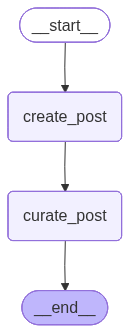

In [12]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()

from IPython.display import Image, display

Image(messages_graph.get_graph().draw_mermaid_png())



In [13]:
messages_graph.invoke(
    {"messages_manual": [HumanMessage(content="The importance of data privacy in the digital age")] }
)

{'messages_manual': [HumanMessage(content='The importance of data privacy in the digital age', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Data privacy has become increasingly crucial in the digital age, reflecting the growing concerns about how personal information is collected, used, and shared. Here are several key reasons illustrating the importance of data privacy:\n\n1. **Protection of Personal Information**: Individuals share vast amounts of personal data online, including sensitive information like financial details, health records, and personal communications. Protecting this data is essential to prevent unauthorized access and misuse.\n\n2. **Trust and Reputation**: Organizations that prioritize data privacy foster trust among their customers. When individuals believe that their data is safe, they are more likely to engage with a business, leading to stronger customer relationships and enhanced brand loyalty.\n\n3. **Legal Compliance**: Many countries ha